In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
                                                     
from scipy.spatial import cKDTree
import datetime as dt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print("done")


done


In [2]:
class HandlerBoxPlot(HandlerBase):
    def __init__(self, sx=1.0, sy=1.8, lw=2.0,
                 box_h_frac=0.75, box_w_frac=0.55,             
                 whisk_out_frac=0.35, cap_hfrac=0.30, **kwargs):
        """
        sx/sy      : 整体横/纵放大
        lw         : 线宽
        box_h_frac : 箱体高度占整个小图标高度的比例
        box_w_frac : 箱体宽度占整个小图标宽度的比例（越小越短）
        whisk_out_frac : 胡须从箱体边缘再向外伸出的比例（相对于箱体宽度）
        cap_hfrac  : 胡须端帽的高度占比
        """
        super().__init__(**kwargs)
        self.sx, self.sy = sx, sy
        self.lw = lw
        self.box_h_frac = box_h_frac
        self.box_w_frac = box_w_frac
        self.whisk_out_frac = whisk_out_frac
        self.cap_hfrac = cap_hfrac

    def create_artists(self, legend, orig_handle, x0, y0, w, h, fontsize, trans):
        sx, sy = self.sx, self.sy
        lw = self.lw
        bhf = self.box_h_frac
        bwf = self.box_w_frac
        wf  = self.whisk_out_frac
        chf = self.cap_hfrac

               
        xc, yc = x0 + w/2, y0 + h/2
        w, h = w*sx, h*sy
        x0, y0 = xc - w/2, yc - h/2

              
        box_w = w * bwf
        box_x = x0 + (w - box_w) / 2      
        box_h = h * bhf
        box_y = y0 + (h - box_h) / 2

              
        whisk = box_w * wf
        y_mid = y0 + h/2

             
        box = Rectangle((box_x, box_y), box_w, box_h,
                        fill=False, edgecolor='k', lw=lw, transform=trans)

             
        med = Line2D([box_x + box_w/2, box_x + box_w/2],
                     [box_y, box_y + box_h],
                     color='orange', lw=lw, transform=trans)

            
        wl  = Line2D([box_x - whisk, box_x], [y_mid, y_mid],
                     color='k', lw=lw, transform=trans)
        wr  = Line2D([box_x + box_w, box_x + box_w + whisk], [y_mid, y_mid],
                     color='k', lw=lw, transform=trans)

            
        capl = Line2D([box_x - whisk, box_x - whisk],
                      [y_mid - chf*h/2, y_mid + chf*h/2],
                      color='k', lw=lw, transform=trans)
        capr = Line2D([box_x + box_w + whisk, box_x + box_w + whisk],
                      [y_mid - chf*h/2, y_mid + chf*h/2],
                      color='k', lw=lw, transform=trans)

        return [wl, wr, capl, capr, box, med]


In [3]:
                                                          
          
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
        
                                                                                            
                                                                        
                                                                                             
                                                                         

           
                                                                                         
                                                            


filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h3.YYYY-MM-DD-00000.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/'
                 'MUSICA_production3.0_NOBB.cam.h3.YYYY-MM-DD-00000.nc')


                                                                                         
                                                                     
                                                                                              
                                                                          

start_date = datetime.date(2017, 12, 2)
end_date   = datetime.date(2018, 11, 30)

                                        
                                          

                    
city_lonlat = {
    'London':    [360 - 0.213492,  51.521050],
    'Manchester':[360 - 2.237881, 53.481520],
                                               
    'Glasgow':   [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
                                           
                                           
                                           
}


In [4]:
                            
import datetime
import os

def collect_files(template, start, end):
    """
    根据模板自动判断是按天(含DD)还是按月(不含DD)收集文件。
    支持占位符 YYYY / MM / DD。
    """
    files = []
               
    by_day = ("DD" in template)

    cur = start
    while cur <= end:
        YYYY = cur.strftime("%Y")
        MM   = cur.strftime("%m")
        DD   = cur.strftime("%d")

        f = (template
             .replace("YYYY", YYYY)
             .replace("MM", MM)
             .replace("DD", DD))

        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")

            
        if by_day:
            cur += datetime.timedelta(days=1)
        else:
                     
            if cur.month == 12:
                cur = datetime.date(cur.year + 1, 1, 1)
            else:
                cur = datetime.date(cur.year, cur.month + 1, 1)

    if not files:
        raise FileNotFoundError(
            f"No files found for template '{template}' between {start} and {end}."
        )
    return files


def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce')                          
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=9):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['PM25'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

                            
scrip30 = xr.open_dataset(SCRIP_file)
scrip60 = xr.open_dataset(SCRIP_file_ne60)

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")


Datasets loaded!


In [5]:
                                                
Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
             
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )
             
    Index_lonlat_60[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file_ne60
    )


TS     = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city]     = ds_ne30['PM25'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['PM25'].values[:, -1, idx60] * 1e9

time_values      = pd.to_datetime(ds_ne30.time.values)
time_values_nobb = pd.to_datetime(ds_ne60.time.values)

                                      
tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

                     
pm_min_30   = {}
pm_max_30   = {}
pm_min_60   = {}
pm_max_60   = {}
for city, (lon_c, lat_c) in city_lonlat.items():
    mn30, mx30 = get_3x3_minmax(
        ds_ne30, tree_30, lon180_30, lon_c, lat_c, k=9)
    mn60, mx60 = get_3x3_minmax(
        ds_ne60, tree_60, lon180_60, lon_c, lat_c, k=9)
    pm_min_30[city], pm_max_30[city] = mn30, mx30
    pm_min_60[city], pm_max_60[city] = mn60, mx60


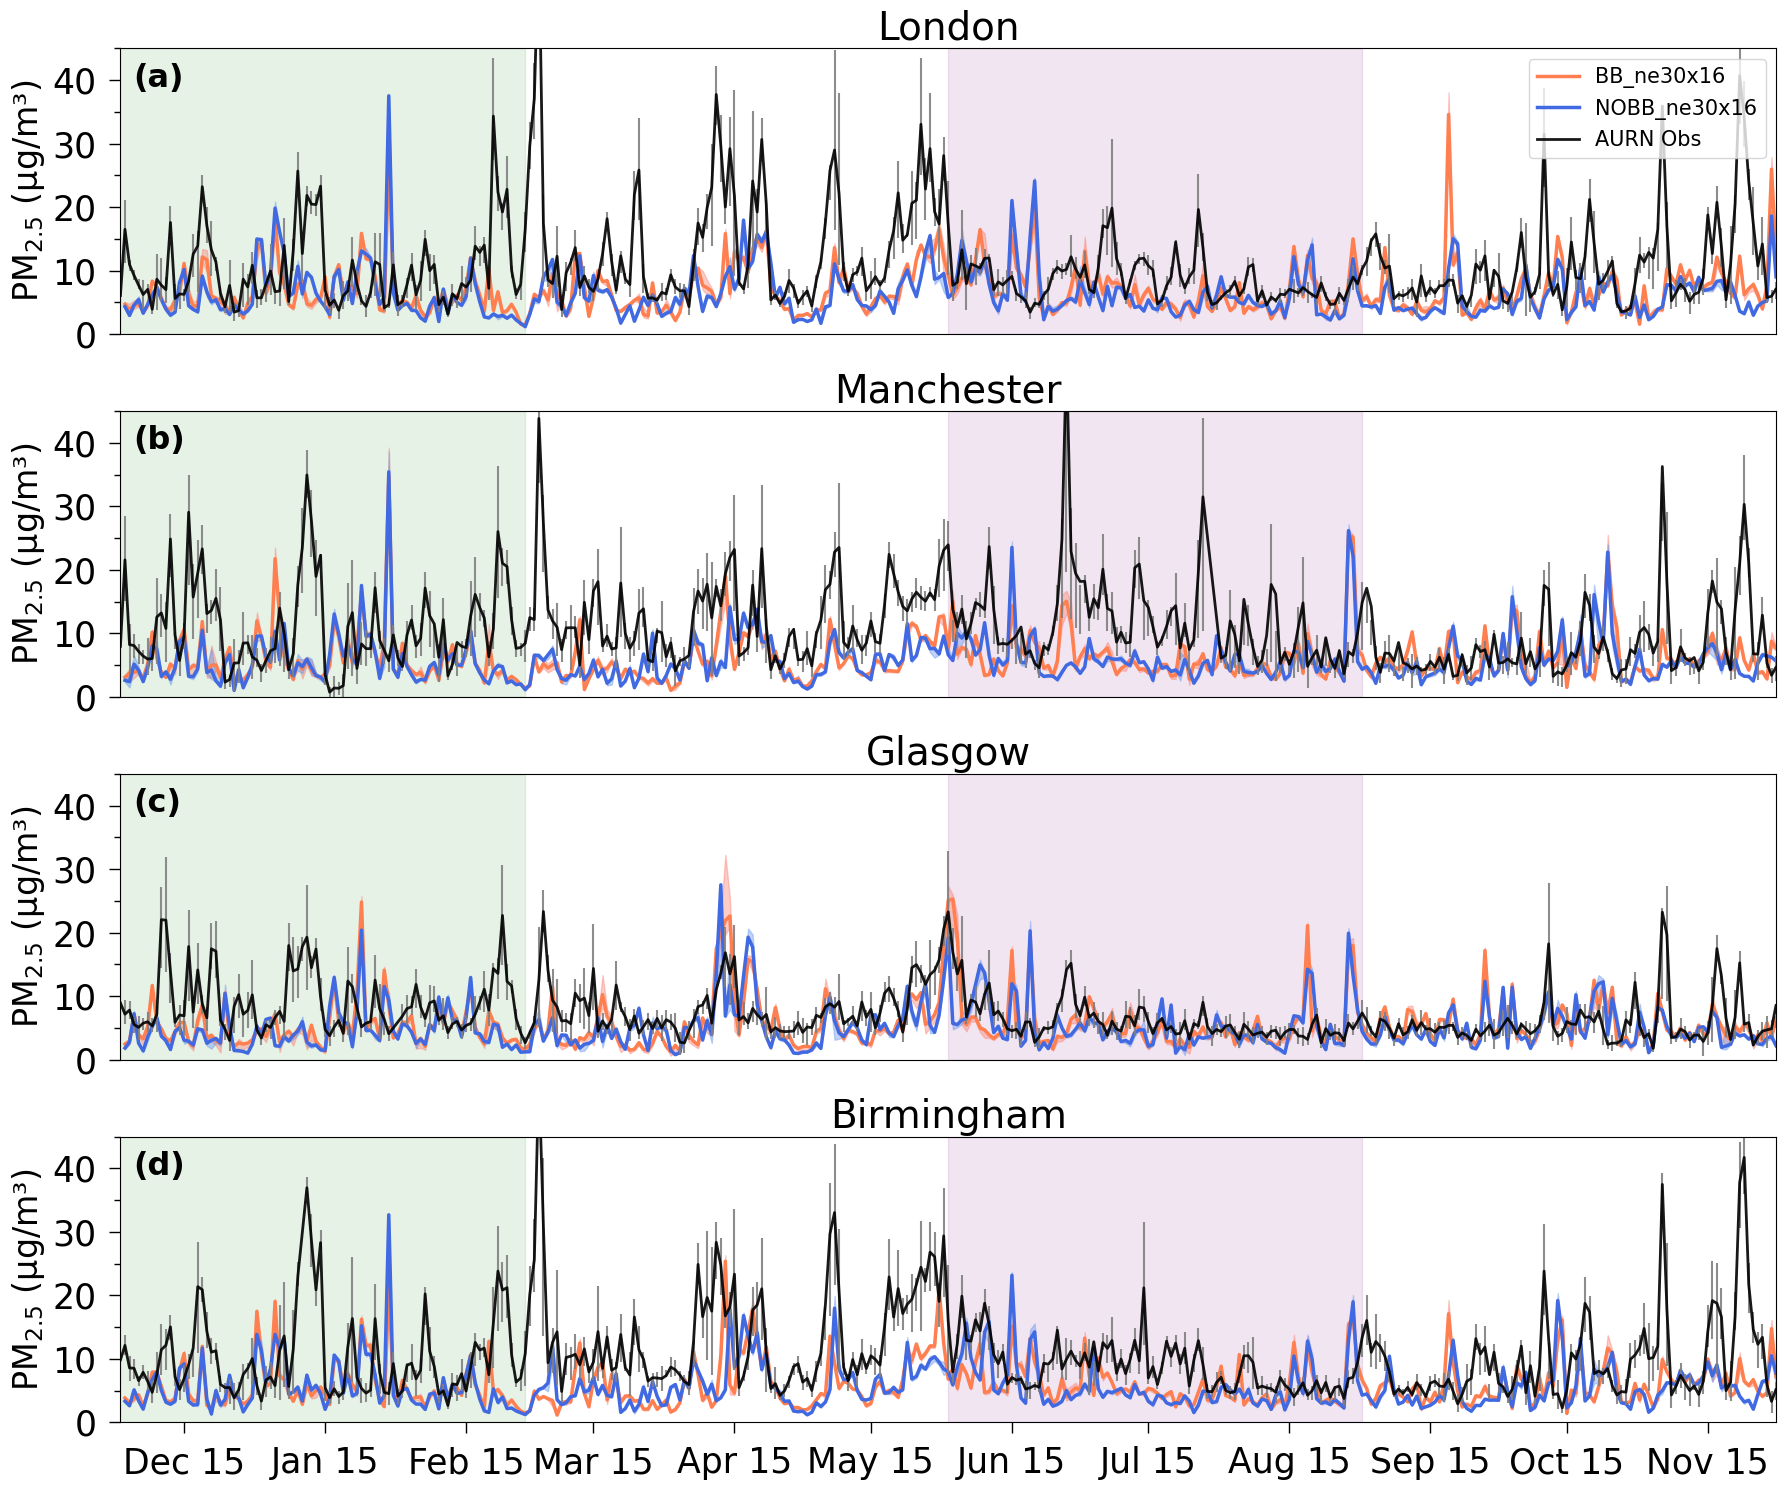

In [21]:
                         
def make_daily_stats(csv_path, ycol='average', start_date=None, end_date=None):
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
    m = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    daily = (
        df.loc[m].set_index('Date')
          .resample('D')[ycol]
          .agg(mean='mean',
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75))
          .reset_index()
          .sort_values('Date')
    )
    return daily

                                       
cities = list(city_lonlat.keys())
fig, axes = plt.subplots(4, 1, figsize=(18, 15))

month_locator   = mdates.MonthLocator(bymonthday=15)  
month_formatter = mdates.DateFormatter('%b %d')

ycol = 'average'
start_date = pd.to_datetime('2017-12-01')
end_date   = pd.to_datetime('2018-12-31')

                             
obs_lon_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/london_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_man_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/manchester_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_gla_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/glasgow_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_bir_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/birmingham_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)

                              
time_values_bst = (pd.to_datetime(time_values.astype('datetime64[ns]'))
                   .tz_localize('UTC')
                   .tz_convert('Europe/London'))
time_values_nobb_bst = (pd.to_datetime(time_values_nobb.astype('datetime64[ns]'))
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))

                                 
obs_daily_map = {
    0: obs_lon_daily,
    1: obs_man_daily,
    2: obs_gla_daily,
    3: obs_bir_daily,
}

for i, city in enumerate(cities):
    ax = axes[i]

            
    ax.fill_between(time_values_bst,      pm_min_30[city], pm_max_30[city], alpha=0.4 , color='salmon')
    ax.plot(time_values_bst,      TS[city].squeeze(),     color='coral',        linewidth=2.5, label='BB_ne30x16')   
    ax.fill_between(time_values_nobb_bst, pm_min_60[city], pm_max_60[city],     alpha=0.4,      color='cornflowerblue')
    ax.plot(time_values_nobb_bst, TS_f09[city].squeeze(), color='royalblue',    linewidth=2.5, label='NOBB_ne30x16')

            
    ax.axvspan(pd.to_datetime('2017-12-01'), pd.to_datetime('2018-02-28'), color='green', alpha=0.1, zorder=0)
    ax.axvspan(pd.to_datetime('2018-06-01'), pd.to_datetime('2018-08-31'), color='purple', alpha=0.1, zorder=0)

                                        
    obs_daily = obs_daily_map[i]
    valid_iqr  = obs_daily.dropna(subset=['q25', 'q75'])
    valid_mean = obs_daily.dropna(subset=['mean'])

              
    ax.vlines(
        valid_iqr['Date'], valid_iqr['q25'], valid_iqr['q75'],
        color='grey', linewidth=1.5, alpha=0.9,
        label=None if i == 0 else None
    )

             
    ax.plot(
        valid_mean['Date'], valid_mean['mean'],
        color='black', linewidth=2, alpha=0.9,
        label='AURN Obs' if i == 0 else None
    )

                                                        
    ax.set_title(city, fontsize=28)
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_formatter)

    plot_start_x = pd.Timestamp('2017-12-01')
    plot_end_x   = pd.Timestamp('2018-11-30')
    ax.set_xlim(pd.Timestamp(plot_start_x), pd.Timestamp(plot_end_x))

    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=25)
        ax.tick_params(axis='x', which='major', labelsize=25, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)

    ax.set_ylabel('PM$_{2.5}$ (µg/m³)', fontsize=24)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylim(0, 45)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='major', labelsize=25, pad=9, length=8, width=1)
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)

                                                                   
    if i == 0:
        ax.legend(fontsize=15, loc='upper right')

          
    letters = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.008, 0.95, letters[i], transform=ax.transAxes, fontsize=23, va='top', ha='left', weight='bold')

plt.tight_layout(h_pad=1.3)


In [8]:
                                          
figure_data_dir = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data'
os.makedirs(figure_data_dir, exist_ok=True)

figure_name = 'FigureS11'

                                                                              
def _to_naive_datetime_index(values):
    idx = pd.DatetimeIndex(values)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    return idx

city_names = list(cities)
time_bb = _to_naive_datetime_index(time_values_bst)
time_nobb = _to_naive_datetime_index(time_values_nobb_bst)

obs_time = pd.DatetimeIndex(
    sorted(
        set().union(*[
            pd.DatetimeIndex(obs_daily_map[i]['Date'].dropna())
            for i in range(len(city_names))
        ])
    )
)

bb_pm25 = np.vstack([np.asarray(TS[city]).squeeze() for city in city_names])
bb_pm25_min = np.vstack([np.asarray(pm_min_30[city]).squeeze() for city in city_names])
bb_pm25_max = np.vstack([np.asarray(pm_max_30[city]).squeeze() for city in city_names])

nobb_pm25 = np.vstack([np.asarray(TS_f09[city]).squeeze() for city in city_names])
nobb_pm25_min = np.vstack([np.asarray(pm_min_60[city]).squeeze() for city in city_names])
nobb_pm25_max = np.vstack([np.asarray(pm_max_60[city]).squeeze() for city in city_names])

obs_mean = np.full((len(city_names), len(obs_time)), np.nan)
obs_q25 = np.full_like(obs_mean, np.nan, dtype=float)
obs_q75 = np.full_like(obs_mean, np.nan, dtype=float)

for i, city in enumerate(city_names):
    obs_daily = obs_daily_map[i].set_index('Date').reindex(obs_time)
    obs_mean[i, :] = obs_daily['mean'].to_numpy(dtype=float)
    obs_q25[i, :] = obs_daily['q25'].to_numpy(dtype=float)
    obs_q75[i, :] = obs_daily['q75'].to_numpy(dtype=float)

figure_s11_ds = xr.Dataset(
    data_vars={
        'BB_ne30x16_PM25': (('city', 'time_bb'), bb_pm25),
        'BB_ne30x16_PM25_3x3_min': (('city', 'time_bb'), bb_pm25_min),
        'BB_ne30x16_PM25_3x3_max': (('city', 'time_bb'), bb_pm25_max),
        'NOBB_ne30x16_PM25': (('city', 'time_nobb'), nobb_pm25),
        'NOBB_ne30x16_PM25_3x3_min': (('city', 'time_nobb'), nobb_pm25_min),
        'NOBB_ne30x16_PM25_3x3_max': (('city', 'time_nobb'), nobb_pm25_max),
        'AURN_obs_daily_mean_PM25': (('city', 'obs_time'), obs_mean),
        'AURN_obs_daily_q25_PM25': (('city', 'obs_time'), obs_q25),
        'AURN_obs_daily_q75_PM25': (('city', 'obs_time'), obs_q75),
        'season_shading_start': (('season',), pd.to_datetime(['2017-12-01', '2018-06-01'])),
        'season_shading_end': (('season',), pd.to_datetime(['2018-02-28', '2018-08-31'])),
    },
    coords={
        'city': city_names,
        'time_bb': time_bb,
        'time_nobb': time_nobb,
        'obs_time': obs_time,
        'season': ['winter', 'summer'],
    }
)

nc_path = os.path.join(figure_data_dir, f'{figure_name}.nc')
figure_s11_ds.to_netcdf(nc_path)

print(f'Saved {figure_name} data to:')
print(nc_path)


Saved FigureS11 data to:
/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS11.nc


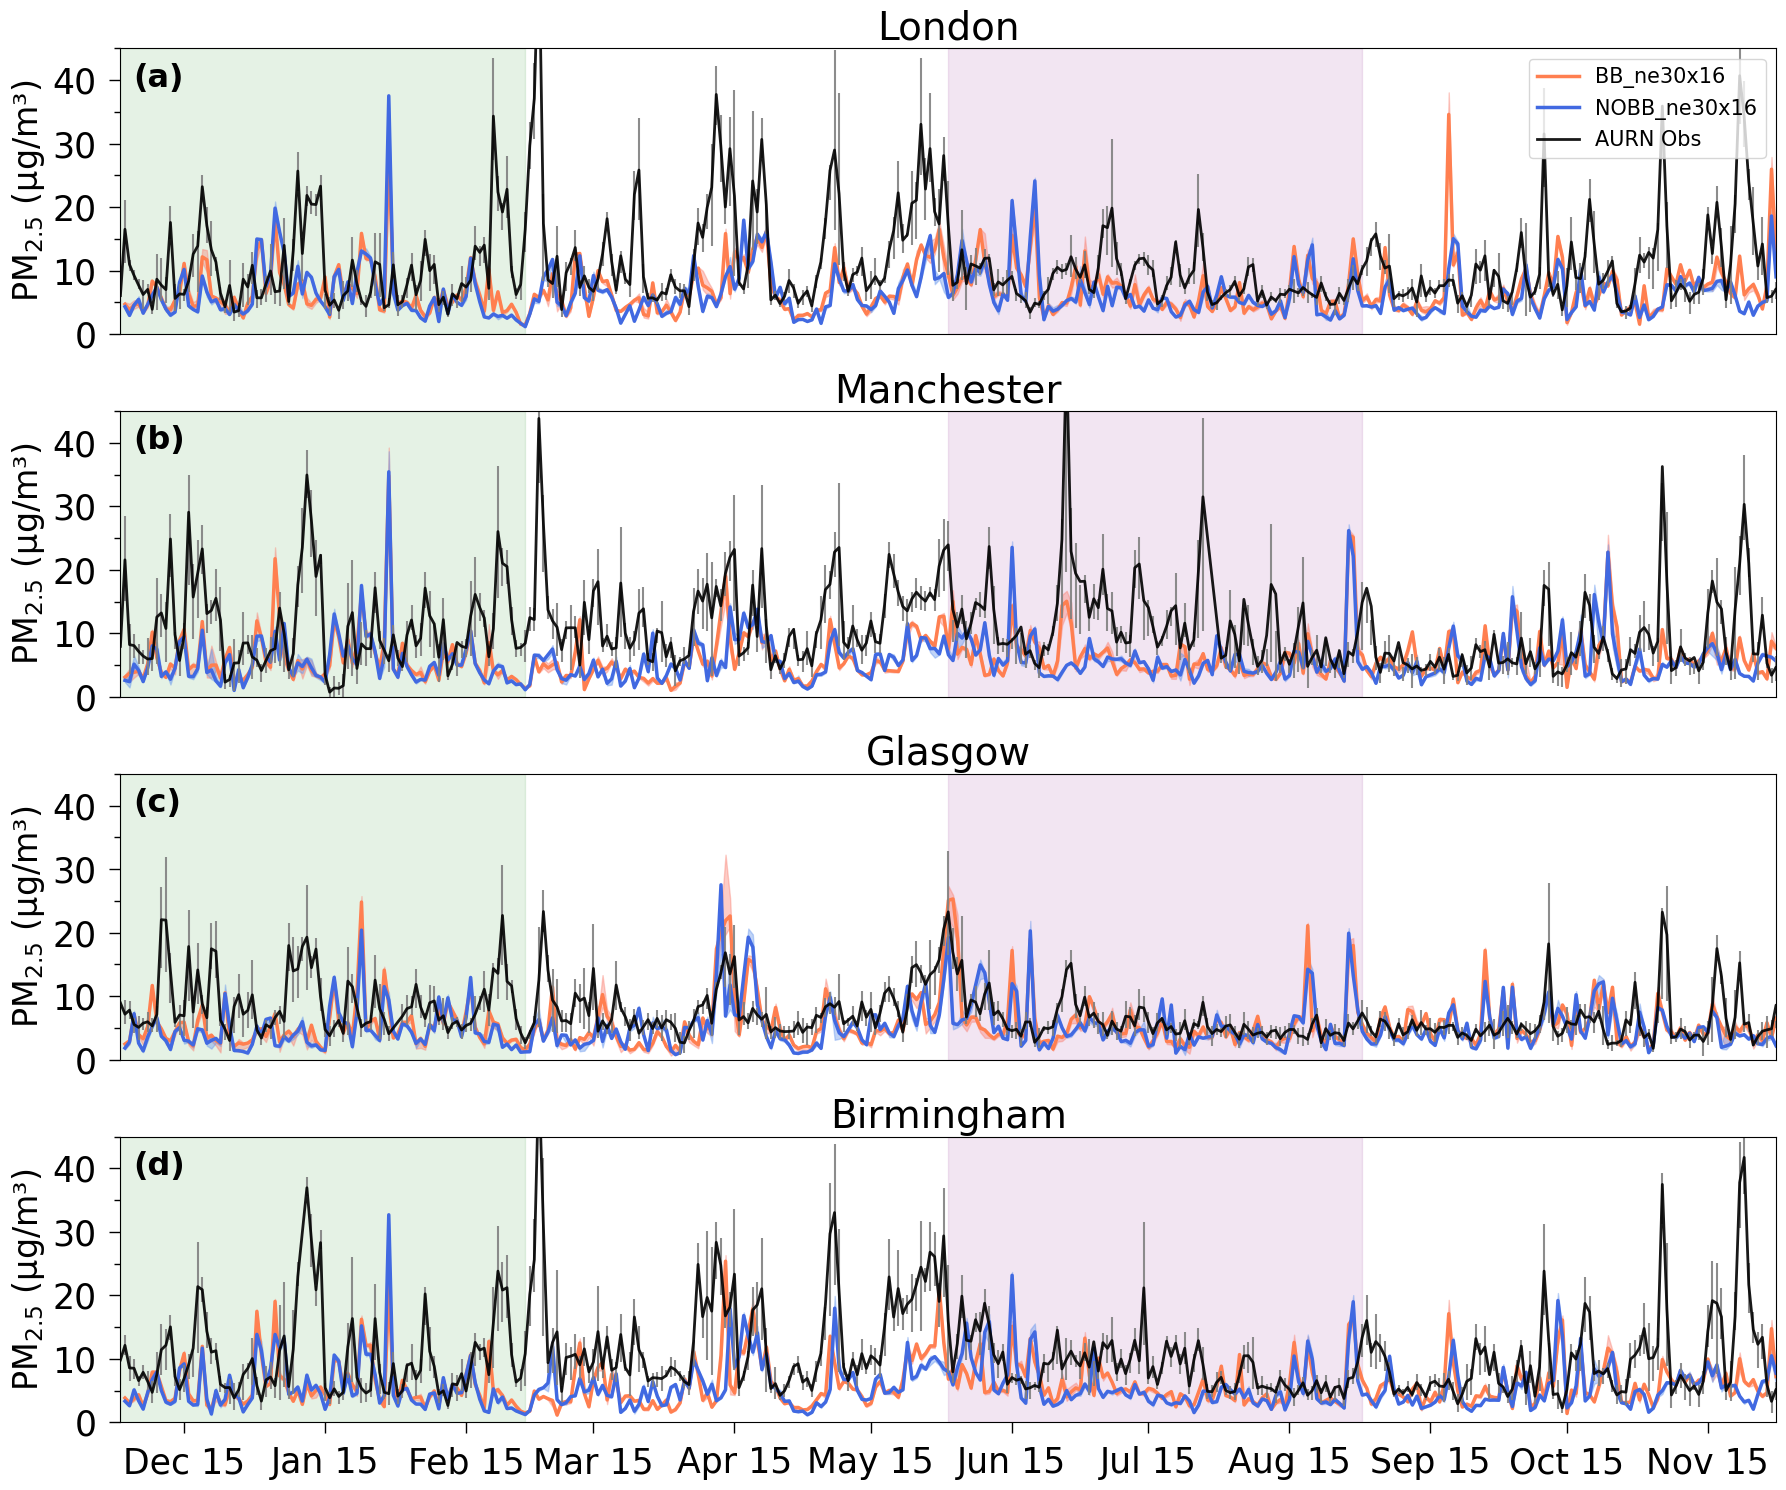

In [20]:
                                             
figure_name = 'FigureS11'
nc_path = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS11.nc'
figure_s11_ds = xr.open_dataset(nc_path)

cities_from_nc = [str(city) for city in figure_s11_ds['city'].values]
fig, axes = plt.subplots(4, 1, figsize=(18, 15))

month_locator = mdates.MonthLocator(bymonthday=15)
month_formatter = mdates.DateFormatter('%b %d')

plot_start_x = pd.Timestamp('2017-12-01')
plot_end_x = pd.Timestamp('2018-11-30')

season_starts = pd.to_datetime(figure_s11_ds['season_shading_start'].values)
season_ends = pd.to_datetime(figure_s11_ds['season_shading_end'].values)
season_colors = ['green', 'purple']

time_bb = pd.to_datetime(figure_s11_ds['time_bb'].values)
time_nobb = pd.to_datetime(figure_s11_ds['time_nobb'].values)
obs_time = pd.to_datetime(figure_s11_ds['obs_time'].values)

for i, city in enumerate(cities_from_nc):
    ax = axes[i]

    bb_pm25 = figure_s11_ds['BB_ne30x16_PM25'].sel(city=city).values
    bb_min = figure_s11_ds['BB_ne30x16_PM25_3x3_min'].sel(city=city).values
    bb_max = figure_s11_ds['BB_ne30x16_PM25_3x3_max'].sel(city=city).values

    nobb_pm25 = figure_s11_ds['NOBB_ne30x16_PM25'].sel(city=city).values
    nobb_min = figure_s11_ds['NOBB_ne30x16_PM25_3x3_min'].sel(city=city).values
    nobb_max = figure_s11_ds['NOBB_ne30x16_PM25_3x3_max'].sel(city=city).values

    obs_mean = figure_s11_ds['AURN_obs_daily_mean_PM25'].sel(city=city).values
    obs_q25 = figure_s11_ds['AURN_obs_daily_q25_PM25'].sel(city=city).values
    obs_q75 = figure_s11_ds['AURN_obs_daily_q75_PM25'].sel(city=city).values

    ax.fill_between(time_bb, bb_min, bb_max, alpha=0.4, color='salmon', rasterized=True)
    ax.plot(time_bb, bb_pm25, color='coral', linewidth=2.5, label='BB_ne30x16', rasterized=True)
    ax.fill_between(time_nobb, nobb_min, nobb_max, alpha=0.4, color='cornflowerblue', rasterized=True)
    ax.plot(time_nobb, nobb_pm25, color='royalblue', linewidth=2.5, label='NOBB_ne30x16', rasterized=True)

    for season_start, season_end, season_color in zip(season_starts, season_ends, season_colors):
        ax.axvspan(season_start, season_end, color=season_color, alpha=0.1, zorder=0, rasterized=True)

    valid_iqr = np.isfinite(obs_q25) & np.isfinite(obs_q75)
    valid_mean = np.isfinite(obs_mean)

    ax.vlines(
        obs_time[valid_iqr], obs_q25[valid_iqr], obs_q75[valid_iqr],
        color='grey', linewidth=1.5, alpha=0.9,
        label=None if i == 0 else None,
        rasterized=True
    )

    ax.plot(
        obs_time[valid_mean], obs_mean[valid_mean],
        color='black', linewidth=2, alpha=0.9,
        label='AURN Obs' if i == 0 else None,
        rasterized=True
    )

    ax.set_title(city, fontsize=28)
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_formatter)
    ax.set_xlim(pd.Timestamp(plot_start_x), pd.Timestamp(plot_end_x))

    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=25)
        ax.tick_params(axis='x', which='major', labelsize=25, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)

    ax.set_ylabel('PM$_{2.5}$ (µg/m³)', fontsize=24)
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylim(0, 45)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='major', labelsize=25, pad=9, length=8, width=1)
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)

    if i == 0:
        ax.legend(fontsize=15, loc='upper right')

    letters = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.008, 0.95, letters[i], transform=ax.transAxes, fontsize=23, va='top', ha='left', weight='bold')

plt.tight_layout(h_pad=1.3)



figures_dir = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures'
os.makedirs(figures_dir, exist_ok=True)

pdf_path = os.path.join(figures_dir, 'FigureS11.pdf')
png_path = os.path.join(figures_dir, 'FigureS11.png')

fig.savefig(pdf_path, dpi=400, bbox_inches='tight')
fig.savefig(png_path, dpi=400, bbox_inches='tight')
